In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import preprocess_fun as fun

from geomstats.geometry.pre_shape import PreShapeSpace
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.learning.incremental_frechet_mean import IncrementalFrechetMean

In [2]:
def reconstruct(df):
    arr = df.to_numpy()
    arr = arr.reshape(df.shape[0], df.shape[1]//2, 2)
    arr = arr.transpose(1, 0, 2)
    return arr

In [3]:
ncl_f = pd.read_csv('NCLdataF.csv', header=None)
ncl_m = pd.read_csv('NCLdataM.csv', header=None)
adl_f = pd.read_csv('ADLdataF.csv', header=None)
adl_m = pd.read_csv('ADLdataM.csv', header=None)
ncl_f = pd.concat([ncl_f, pd.DataFrame([ncl_f.iloc[0]])], ignore_index=True)
ncl_m = pd.concat([ncl_m, pd.DataFrame([ncl_m.iloc[0]])], ignore_index=True)
adl_f = pd.concat([adl_f, pd.DataFrame([adl_f.iloc[0]])], ignore_index=True)
adl_m = pd.concat([adl_m, pd.DataFrame([adl_m.iloc[0]])], ignore_index=True)

In [4]:
con_f = reconstruct(ncl_f)
con_m = reconstruct(ncl_m)
alz_f = reconstruct(adl_f)
alz_m = reconstruct(adl_m)
ucon_f = fun.unify(con_f)
ucon_m = fun.unify(con_m)
ualz_f = fun.unify(alz_f)
ualz_m = fun.unify(alz_m)
ucc = np.concatenate((ucon_f, ucon_m, ualz_f, ualz_m), axis = 0)

In [5]:
k_landmark = 51
m_ambient = 2
preshape = PreShapeSpace(k_landmark, m_ambient)
preshape.equip_with_group_action('rotations')
preshape.equip_with_quotient()

ucc_preshape = preshape.projection(ucc)

mean_frechet = FrechetMean(preshape)
mean_incremental = IncrementalFrechetMean(preshape)

ucc_mean_frechet = mean_frechet.fit(ucc_preshape).estimate_
ucc_mean_incremental = mean_incremental.fit(ucc_preshape).estimate_
ucc_mean_recursive = fun.Rec_Frechet_mean_geom(ucc)



(-0.22374884668374687,
 0.21982855298794263,
 -0.0746371961860443,
 0.11013317265612568)

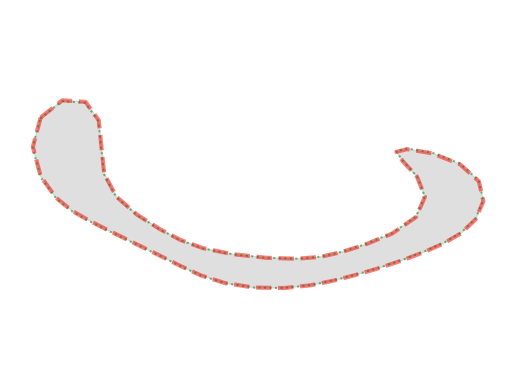

In [6]:
plt.fill(ucc_mean_frechet[:,1], ucc_mean_frechet[:,0], color = 'silver', alpha = 0.5, label = 'FM')
plt.plot(ucc_mean_incremental[:,1], ucc_mean_incremental[:,0], linestyle='--', color = 'r', alpha = 0.5, linewidth = 3, label = 'iFME')
plt.plot(ucc_mean_recursive[:,1], ucc_mean_recursive[:,0], linestyle=':', color = 'g', alpha = 0.5, label = 'RFME')
plt.axis('equal')
plt.axis('off')

In [7]:
eFM_TE = 0
iFME_TE = 0
RFME_TE = 0
for i in range(ucc_preshape.shape[0]):
    eFM_TE += preshape.quotient.metric.dist(ucc_mean_frechet, ucc_preshape[i])
    iFME_TE += preshape.quotient.metric.dist(ucc_mean_incremental, ucc_preshape[i])
    RFME_TE += preshape.quotient.metric.dist(ucc_mean_recursive, ucc_preshape[i])

In [8]:
print('eFM:', eFM_TE, '\niFME:', iFME_TE, '\nRFME:', RFME_TE)

eFM: 24.25986466320177 
iFME: 24.259173083819313 
RFME: 24.258322167035857


In [9]:
print('eFM:', fun.SSE(ucc_mean_frechet, ucc_preshape), '\niFME:', fun.SSE(ucc_mean_incremental, ucc_preshape), '\nRFME:', fun.SSE(ucc_mean_recursive, ucc_preshape))

eFM: 1.620930033799753 
iFME: 1.6209096109191607 
RFME: 1.6207927753044151
